# Dynamic `(batch, seq_len, mode)` → time and average power

**Runs on a free Colab CPU runtime. Nothing runs on your machine — every line of code is pulled from GitHub.**

### The problem

EnergAIzer predicts per-kernel latency, power and energy from a **traced** workload file: a flat JSON list of
kernels captured by running the real model once, on a real GPU, at one fixed input shape. The shipped GPT-2
files are literally named

```
gpt2model_gpt2_pbf16_b8_s128_modeprefill.json
                      ^^  ^^^^  ^^^^^^^
                   batch  seqlen  mode
```

so **every shape you can evaluate is a shape somebody already traced.** Ask for `batch=13, seq_len=377` and
there is no file.

### The fix

Trace **three** times, then derive every other shape arithmetically. Every numeric field in a traced entry is
a monomial in the input dimensions — `value = const × B^a × S^b` — and the exponents fall out by differencing
three traces that each move one input.

### What this notebook does

1. clones the code from GitHub and runs its **107 tests**
2. learns the scaling law from three anchor traces
3. proves it reproduces **all 25 shipped templates exactly**
4. produces a shape nobody ever traced
5. shows why `mode` is a third axis and not a rescaling
6. runs a **random shape stream** through the predictor and plots **time vs average power**

## 1 — Clone the code from GitHub

In [1]:
import os, subprocess, sys

REPO_URL = "https://github.com/shubhamOjha1000/dynamic_shape_power_sim.git"
ROOT     = "/content/dynamic_shape_power_sim"

if not os.path.isdir(ROOT):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, ROOT], check=True)
else:
    subprocess.run(["git", "-C", ROOT, "pull", "--ff-only"], check=False)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "numpy", "pandas", "matplotlib", "pytest"], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

print("code at:", ROOT)
print(subprocess.run(["git", "-C", ROOT, "log", "-1", "--oneline"],
                     capture_output=True, text=True).stdout.strip())

code at: /content/dynamic_shape_power_sim
9c00d2b dynshape: dynamic (batch, seq_len, mode) shapes for EnergAIzer


## 2 — Run the test suite

107 tests. The important one is `test_rewrite_matches_every_shipped_template`: it is parametrised over the
whole `5 × 5` grid of shipped GPT-2 templates and asserts **exact equality**, field for field, against files
that were traced independently on real hardware.

In [2]:
import subprocess, sys
print(subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:warnings", "tests/"],
                     capture_output=True, text=True).stdout[-2500:])

........................................................................ [ 67%]
...................................                                      [100%]
107 passed in 3.25s



## 3 — (Optional) the real EnergAIzer predictor

Two backends sit behind one interface:

| Backend | Needs | Gives you |
|---|---|---|
| `GeeBackend` | the EnergAIzer LUT database (~500 MB, separate download) | real numbers — 3.1–3.8% MAPE per kernel type |
| `AnalyticBackend` | nothing | a **SYNTHETIC** roofline stand-in so everything runs anyway |

Leave `USE_REAL_ENERGAIZER = False` for a fast pass — the shape machinery, the tests and the graphs are all
identical either way, only the wattages change. Flip it to `True` to pull the framework and the LUT.

Every figure is stamped with which backend produced it, so a synthetic number can never be mistaken for a
measured one.

In [3]:
USE_REAL_ENERGAIZER = False        # flip to True to download the LUT (~500 MB)

PKG_PATH = LUT_DIR = None

if USE_REAL_ENERGAIZER:
    import glob, subprocess, sys, os
    EN_ROOT = "/content/single_kernel_GPU_model"
    PKG_PATH = os.path.join(EN_ROOT, "energaizer-ispass26-artifact-main")
    if not os.path.isdir(PKG_PATH):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/shubhamOjha1000/single_kernel_GPU_model.git",
                        EN_ROOT], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "scipy", "cvxpy", "pyyaml", "opt-einsum", "tqdm",
                    "scikit-learn", "gdown"], check=True)

    LUT_DIR = os.path.join(PKG_PATH, "database", "data")
    os.makedirs(LUT_DIR, exist_ok=True)
    if not glob.glob(os.path.join(LUT_DIR, "**", "*.csv"), recursive=True):
        import gdown
        archive = os.path.join(LUT_DIR, "precollected_database.tar.gz")
        gdown.download(id="1krvqRFDnaqrJUT06V2psIua0wQr6ETAE", output=archive, quiet=False)
        subprocess.run(["tar", "-xzf", archive, "-C", LUT_DIR], check=True)
        os.remove(archive)

    # The LUT config resolves CSVs by bare filename, so flatten the layout.
    for csv in glob.glob(os.path.join(LUT_DIR, "**", "*.csv"), recursive=True):
        dest = os.path.join(LUT_DIR, os.path.basename(csv))
        if os.path.abspath(csv) != os.path.abspath(dest) and not os.path.exists(dest):
            os.symlink(os.path.abspath(csv), dest)
    print("LUT csv files:", len(glob.glob(os.path.join(LUT_DIR, "*.csv"))))
else:
    print("using the SYNTHETIC analytic backend (no LUT needed)")

using the SYNTHETIC analytic backend (no LUT needed)


## 4 — Learn the scaling law

Three anchor traces go in. Out comes, per entry per field, the pair of exponents `(a, b)` on `(batch, seqlen)`.

A non-integer exponent raises `ValueError` rather than being rounded — if `value = const × B^a × S^b` does not
hold for some field, you want that loud, not silently baked into every downstream prediction.

In [4]:
from collections import Counter
from dynshape import ShapeRewriter, split_seq_exponent

rw = ShapeRewriter.from_dir("templates/gpt2")     # anchors: b8_s128, b16_s128, b8_s512

print(f"{rw.n_kernels()} kernels per forward pass, anchored at b{rw.b0} s{rw.s0}\n")
print(f"{'count':>6}  {'op':<26} {'field':<8} {'a':>3} {'b':>3}   {'Sq':>3} {'Sk':>3}")
print("-" * 62)

counts = Counter()
for (q, op), r in zip(rw.base, rw.rules):
    for k, (a, b) in r.items():
        counts[(op, k, a, b) + split_seq_exponent(op, k, b)] += 1

for (op, field, a, b, p, kk), n in counts.most_common():
    print(f"{n:>6}  {' '.join(op):<26} {field:<8} {a:>3} {b:>3}   {p:>3} {kk:>3}")

242 kernels per forward pass, anchored at b8 s128

 count  op                         field      a   b    Sq  Sk
--------------------------------------------------------------
   121  elementwise                dim        1   1     1   0
    60  gemm tc bf16_bf16          dimN       0   0     0   0
    60  gemm tc bf16_bf16          dimK       0   0     0   0
    48  gemm tc bf16_bf16          batch      0   0     0   0
    48  gemm tc bf16_bf16          dimM       1   1     1   0
    25  layernorm bf16             batch      1   1     1   0
    25  layernorm bf16             dim        0   0     0   0
    24  gemm tc bf16_bf16          batch      1   0     0   0
    24  gemm tc bf16_bf16          dimM       0   1     1   0
    12  gemm tc bf16_bf16          dimN       0   1     0   1
    12  elementwise                dim        1   2     1   1
    12  softmax bf16               batch      1   1     1   0
    12  softmax bf16               dim        0   1     0   1
    12  gemm tc bf

**Read the table.** `a` and `b` are the learned exponents on batch and sequence. `Sq` and `Sk` are the
query/key split used for decode (§6) — they always sum to `b`.

The row worth staring at is `elementwise dim` with `b = 2`. Its base value is `1572864`, which is *both*
`2 × 786432` and `B·heads·S²`. From one traced file you could not tell which; only differencing settles it.
That is the entire argument for this approach over hand-written per-kernel rules.

## 5 — The proof: reproduce all 25 shipped templates exactly

`b ∈ {1,2,8,16,32} × s ∈ {128,512,1024,2048,4096}` — 22 of them were never shown to the rewriter. Not
"within 5%": `assert generated == reference`, every field of all 242 entries.

In [5]:
from dynshape import load_template

ok = 0
print(f"{'':6}" + "".join(f"{s:>8}" for s in (128, 512, 1024, 2048, 4096)))
for b in (1, 2, 8, 16, 32):
    row = f"b={b:<4}"
    for s in (128, 512, 1024, 2048, 4096):
        ref = load_template(f"templates/gpt2/gpt2model_gpt2_pbf16_b{b}_s{s}_modeprefill.json")
        match = rw.expand(b, s, "prefill") == ref
        ok += match
        row += f"{'  exact' if match else '  FAIL':>8}"
    print(row)

print(f"\n{ok}/25 templates reproduced exactly "
      f"({242 * 25:,} entries, every numeric field)")

           128     512    1024    2048    4096
b=1      exact   exact   exact   exact   exact
b=2      exact   exact   exact   exact   exact
b=8      exact   exact   exact   exact   exact
b=16     exact   exact   exact   exact   exact
b=32     exact   exact   exact   exact   exact

25/25 templates reproduced exactly (6,050 entries, every numeric field)


## 6 — A shape nobody ever traced

`batch=13, seq_len=377`. No file, no measurement, no interpolation table — just the monomial evaluated at a
new point.

In [6]:
kernels = rw.expand(batch=13, seqlen=377, mode="prefill")
print(f"{len(kernels)} kernels for b13 s377 — a shape that was never traced\n")

for q, op in kernels[:6]:
    print(f"  {' '.join(op):<26} {q}")

tokens = 13 * 377
proj = [q["dimM"] for q, op in kernels if op[0] == "gemm" and q.get("batch") == 1]
attn = [q for q, op in kernels if op[0] == "gemm" and q.get("batch") == 13 * 12]
print(f"\n  projection GEMM M  = {proj[0]:,}  == 13 x 377 tokens : {proj[0] == tokens}")
print(f"  attention  batch   = {attn[0]['batch']}    == 13 x 12 heads")
print(f"  attention  M x N    = {attn[0]['dimM']} x {attn[0]['dimN']}   square, because prefill")

242 kernels for b13 s377 — a shape that was never traced

  elementwise                {'dim': 3763968, 'op': 'pointwise_add', 'prec': 'bf16'}
  layernorm bf16             {'batch': 4901, 'dim': 768, 'prec': 'bf16'}
  gemm tc bf16_bf16          {'batch': 1, 'dimM': 4901, 'dimN': 2304, 'dimK': 768, 'precM': 'bf16', 'precA': 'bf16', 'useTensorCore': True}
  gemm tc bf16_bf16          {'batch': 156, 'dimM': 377, 'dimN': 377, 'dimK': 64, 'precM': 'bf16', 'precA': 'bf16', 'useTensorCore': True}
  elementwise                {'dim': 22172124, 'op': 'unspecified_tensor', 'prec': 'bf16'}
  softmax bf16               {'batch': 58812, 'dim': 377, 'prec': 'bf16'}

  projection GEMM M  = 4,901  == 13 x 377 tokens : True
  attention  batch   = 156    == 13 x 12 heads
  attention  M x N    = 377 x 377   square, because prefill


## 7 — `mode` is a third axis, not a rescaling

Prefill attention is a **square** — every token attends to every token. Decode attention is a **strip** — one
query row against the whole KV cache.

```
prefill:  attn GEMM   M = S,  N = S        square
decode:   attn GEMM   M = 1,  N = context  strip
```

No exponent turns a square into a strip. So the sequence exponent `b` is **split** into a query-length
exponent and a key-length exponent, `p + q = b`, giving `value = const × B^a × Sq^p × Sk^q`:

```
prefill(B, S)       →  Sq = S,  Sk = S
decode(B, context)  →  Sq = 1,  Sk = context
```

Because prefill sets `Sq == Sk`, the split is *invisible* there — which means the exact-match proof in §5 also
constrains the decode path. That reduction is itself a test (`test_three_axis_reduces_to_two_axis`).

In [7]:
B, S = 8, 1024
pre = rw.expand(B, S, "prefill")
dec = rw.expand(B, S, "decode")

def show(name, entries):
    proj = next(q for q, op in entries if op[0] == "gemm" and q.get("batch") == 1)
    attn = [q for q, op in entries if op[0] == "gemm" and q.get("batch") == B * 12]
    sm   = next(q for q, op in entries if op[0] == "softmax")
    qk   = next(q for q in attn if q["dimK"] == 64)
    print(f"  {name:<9} projection M = {proj['dimM']:>7,} tokens  |  "
          f"attn {qk['dimM']:>5} x {qk['dimN']:<5}  |  softmax {sm['batch']:>7,} x {sm['dim']:<5}")

print(f"GPT-2, batch={B}, sequence/context={S}\n")
show("prefill", pre)
show("decode", dec)

flops = lambda es: sum(q.get("batch", 1) * q["dimM"] * q["dimN"] * q["dimK"]
                       for q, op in es if op[0] == "gemm")
print(f"\n  prefill does {flops(pre) / flops(dec):,.0f}x the GEMM work of one decode step")

GPT-2, batch=8, sequence/context=1024

  prefill   projection M =   8,192 tokens  |  attn  1024 x 1024   |  softmax  98,304 x 1024 
  decode    projection M =       8 tokens  |  attn     1 x 1024   |  softmax      96 x 1024 

  prefill does 1,024x the GEMM work of one decode step


> **Honest limit.** No decode workload ships with the EnergAIzer artifact — all 90 files are `modeprefill`
> and `grep -c decode` returns 0. The decode rule is derived from what `run_model.get_input()` actually feeds
> the model (one token per sequence plus a length-`seqlen` KV cache) and is checked for *internal* consistency
> only. Structurally sound, empirically unconfirmed.

## 8 — A random shape stream

Random batch sizes, log-uniform sequence lengths, both modes. Deliberately **not** a serving simulator: no
arrival process, no scheduler, no KV admission, no preemption. Those layers decide *which* shapes a real
engine produces; this just emits a varied spread so the shape machinery has something to chew on.

Each generator holds its own `numpy` child streams, so batch, sequence length and mode can each be re-rolled
without disturbing the other two — impossible with one shared global seed.

In [8]:
from dynshape import RandomShapeGenerator, WorkloadConfig, build_predictor, simulate

cfg = WorkloadConfig(
    batch_choices=(1, 2, 4, 8, 16, 32),
    seq_min=128, seq_max=4096,
    seq_round_to=128,          # CUDA-graph style bucketing; also makes the cache hit
    decode_fraction=0.5,
)
requests = RandomShapeGenerator(cfg, seed=0).sample(40)

print(f"{'shape':>24} {'tokens':>10}")
for r in requests[:10]:
    print(f"{r.label:>24} {r.tokens:>10,}")
print(f"{'...':>24}  ({len(requests) - 10} more)")

predictor = build_predictor(pkg_path=PKG_PATH, lut_dir=LUT_DIR, freq=900)
print(f"\nbackend: {predictor.backend.name}")

trace = simulate(requests, rw, predictor)
s = trace.summary()
print(f"""
  passes           {s['requests']}
  kernels          {s['kernels']:,}
  distinct shapes  {s['distinct_shapes']:,}   (cache hit rate {s['hit_rate']*100:.1f}%)
  total time       {s['total_time_ms']:.2f} ms
  total energy     {s['total_energy_j']:.3f} J
  average power    {s['avg_power_w']:.1f} W
  peak power       {s['peak_power_w']:.1f} W""")

                   shape     tokens
       b16_s1408_prefill     22,528
         b32_s384_decode         32
        b1_s1152_prefill      1,152
         b2_s640_prefill      1,280
        b16_s2304_decode         16
        b16_s1920_decode         16
         b2_s896_prefill      1,792
        b1_s1408_prefill      1,408
         b32_s640_decode         32
         b4_s3456_decode          4
                     ...  (30 more)

backend: analytic (SYNTHETIC)

  passes           40
  kernels          9,680
  distinct shapes  393   (cache hit rate 95.9%)
  total time       925.36 ms
  total energy     131.870 J
  average power    142.5 W
  peak power       176.9 W


**Why the cache is mandatory, not an optimisation.** A real EnergAIzer lookup costs on the order of 50 ms.
Look at the numbers above: thousands of kernels collapse to a few hundred distinct *shapes*, because the 12
transformer blocks are 12 literal repetitions of the same kernels and batch sizes recur. Without the cache
this run would take hours; with it, minutes.

## 9 — The graph: time joined with average power

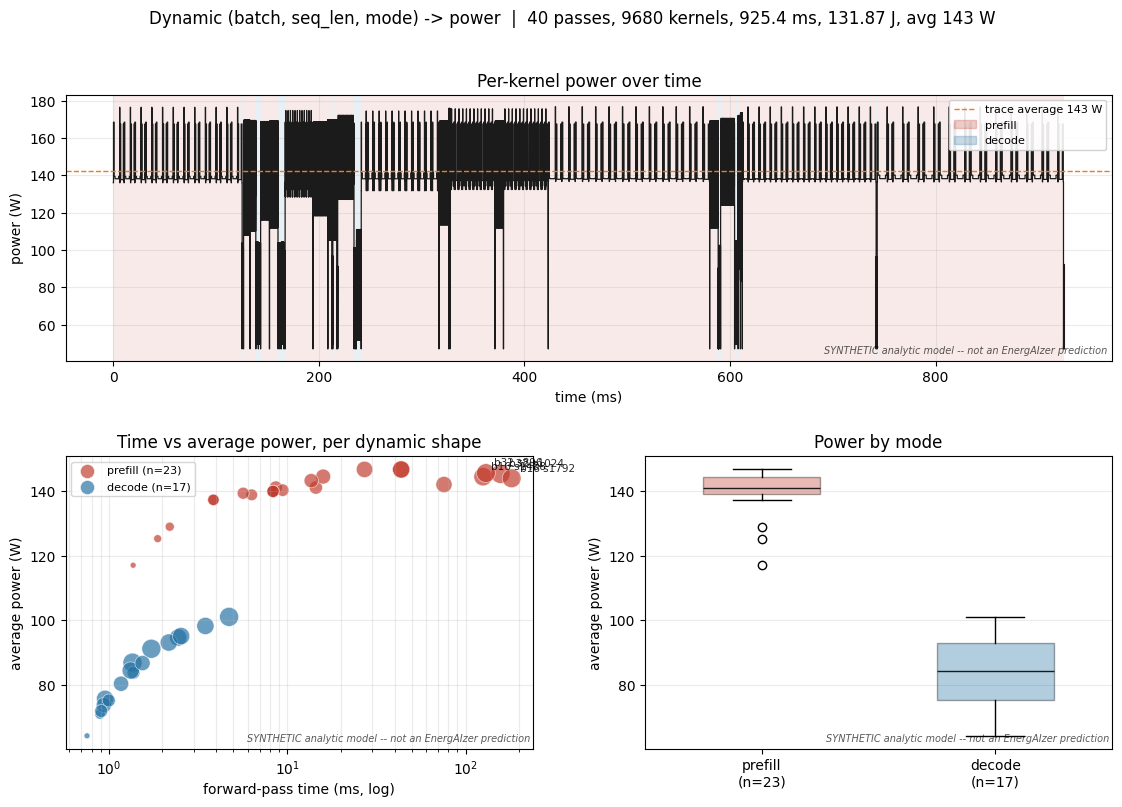

In [9]:
import matplotlib.pyplot as plt
from dynshape.plot import plot_dashboard

fig = plot_dashboard(trace)
plt.show()

**Reading it.**

- **Top — power vs wall clock.** The staircase is the trace itself: one step per kernel, height = that
  kernel's average power. Pink bands are prefill passes, blue are decode. Long flat-ish pink stretches are
  big prefills; the fast dense bursts are decode steps.
- **Bottom left — the join.** One point per forward pass: how long it took (x) against what it drew (y),
  marker area proportional to tokens. Prefill sits up and to the right; decode clusters low and fast. This is
  the *(time, average power)* pair the brief asked for, per dynamic shape.
- **Bottom right — by mode.** The same thing as a distribution. The gap between the two boxes is the
  compute-bound / memory-bound split, and it is the single biggest lever on instantaneous power.

The timeline is dominated by whichever pass is longest. Pass `max_ms=` to zoom:

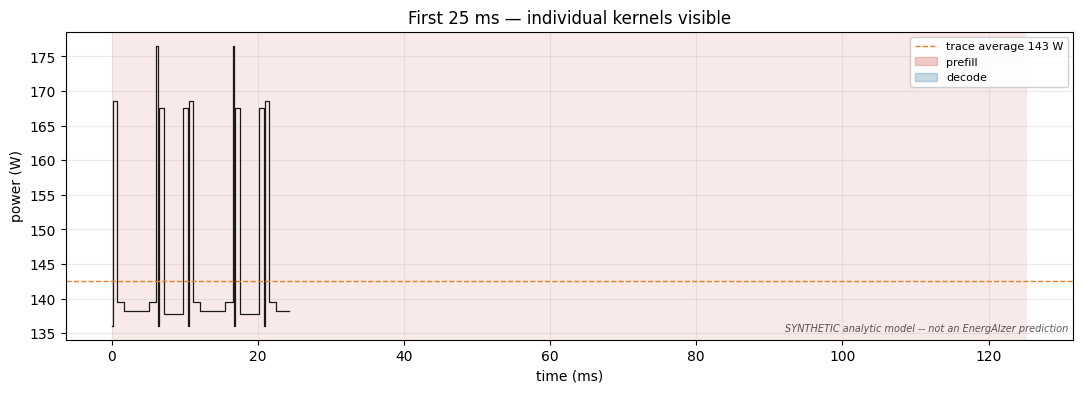

In [10]:
from dynshape.plot import plot_power_timeline

fig, ax = plt.subplots(figsize=(13, 4))
plot_power_timeline(trace, ax=ax, max_ms=25, title="First 25 ms — individual kernels visible")
plt.show()

## 10 — A deterministic sweep

Random shapes show that arbitrary shapes *work*. A grid shows how power and time actually *move* with each
dynamic input — which a random stream alone cannot make legible.

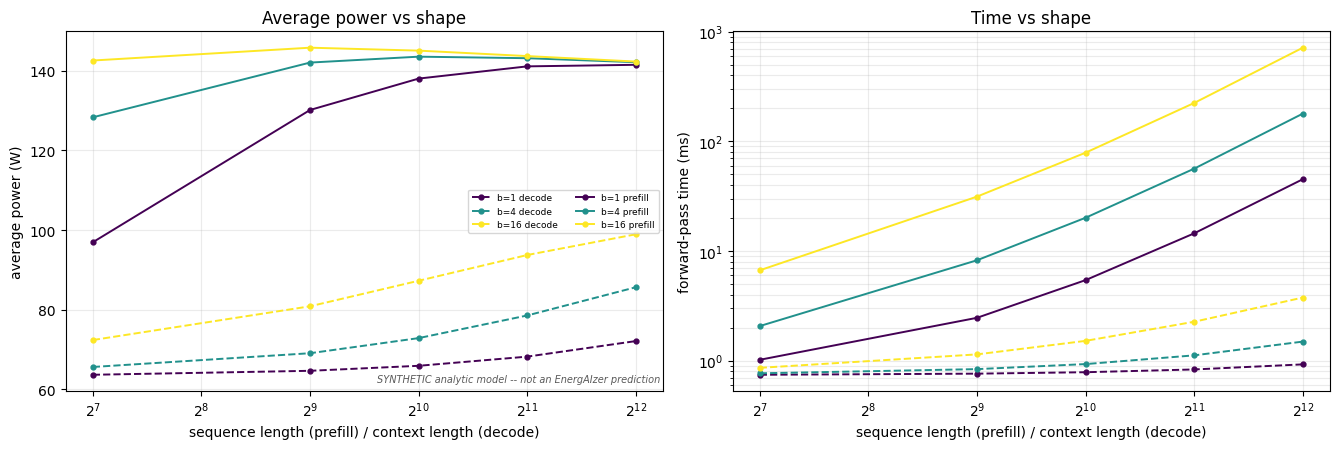

In [11]:
from dynshape import sweep
from dynshape.plot import plot_shape_sweep

grid = simulate(sweep([1, 4, 16], [128, 512, 1024, 2048, 4096]), rw, predictor)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
plot_shape_sweep(grid, axes[0], axes[1])
plt.tight_layout(); plt.show()

Solid lines are prefill, dashed are decode; colour is batch size.

- **Prefill power** rises steeply and then saturates: at batch 1 it climbs 97 W → 141 W between 128 and 4096
  tokens, and at batch 16 it is already flat at ~142–146 W from the shortest sequence on. Once the GEMMs are
  large enough to fill the machine, more tokens buy **time**, not watts.
- **Decode power** stays low throughout — roughly 64 W to 99 W across the whole grid, against 142–146 W for
  a saturated prefill. It climbs gently with context and batch (a longer attention strip, more of it) but one
  token per sequence never fills the machine, and that work is memory-bound rather than compute-bound.
- **Time** separates by orders of magnitude on the log axis — which is exactly why per-kernel resolution
  matters and a single averaged wattage does not.

## 11 — The raw records

In [12]:
kdf, rdf = trace.to_dataframes()

print("per pass:")
display(rdf[["idx", "batch", "seqlen", "mode", "tokens", "time_ms",
             "avg_power_w", "energy_j", "energy_per_token_mj"]].head(12).round(4))

print("\nper kernel (first pass):")
display(kdf[kdf.req_idx == 0][["kernel_idx", "op", "shape", "t_start_ms",
                               "time_ms", "power_w", "energy_j"]].head(12).round(6))

print("\nhottest kernel types:")
display(kdf[kdf.kind == "KERNEL"].groupby("op")
           .agg(n=("power_w", "size"), mean_W=("power_w", "mean"),
                total_ms=("time_ms", "sum"), total_J=("energy_j", "sum"))
           .sort_values("total_J", ascending=False).round(3))

per pass:


,idx,batch,seqlen,mode,tokens,time_ms,avg_power_w,energy_j,energy_per_token_mj
0,0,16,1408,prefill,22528,125.3343,144.4811,18.1084,0.8038
1,1,32,384,decode,32,1.3577,86.9548,0.1181,3.6894
2,2,1,1152,prefill,1152,6.3289,138.8645,0.8789,0.7629
3,3,2,640,prefill,1280,5.6686,139.3645,0.7900,0.6172
4,4,16,2304,decode,16,2.4500,94.7308,0.2321,14.5055
5,5,16,1920,decode,16,2.1693,93.1674,0.2021,12.6317
6,6,2,896,prefill,1792,8.6354,141.1589,1.2190,0.6802
7,7,1,1408,prefill,1408,8.3340,139.9461,1.1663,0.8283
8,8,32,640,decode,32,1.7320,91.2461,0.1580,4.9386
9,9,4,3456,decode,4,1.3745,83.8360,0.1152,28.8085



per kernel (first pass):


,kernel_idx,op,shape,t_start_ms,time_ms,power_w,energy_j
0,0,elementwise,17301504,0.000000,0.080539,136.081536,0.010960
1,1,layernorm bf16,22528x768,0.080539,0.080539,136.081536,0.010960
2,2,gemm tc bf16_bf16,1x22528x2304x768,0.161078,0.535774,168.583801,0.090323
3,3,gemm tc bf16_bf16,192x1408x1408x64,0.696852,0.986356,139.471227,0.137568
4,4,elementwise,380633088,1.683208,1.729860,138.244384,0.239143
5,5,softmax bf16,270336x1408,3.413068,1.729860,138.244384,0.239143
6,6,gemm tc bf16_bf16,192x1408x64x1408,5.142928,0.986356,139.471227,0.137568
7,7,gemm tc bf16_bf16,1x22528x768x768,6.129284,0.179925,176.543981,0.031765
8,8,elementwise,17301504,6.309208,0.080539,136.081536,0.010960
9,9,layernorm bf16,22528x768,6.389748,0.080539,136.081536,0.010960



hottest kernel types:


,n,mean_W,total_ms,total_J
op,,,,
gemm tc bf16_bf16,2880,128.641,378.397,57.622
elementwise,5320,97.231,393.772,53.506
softmax bf16,480,107.969,133.900,18.437
layernorm bf16,1000,88.153,17.293,2.210


---

## Recap

- EnergAIzer's input shape was **fixed to whatever was traced**. Three anchor traces make it **dynamic** —
  any batch, any sequence length, either mode.
- The scaling law is **derived, not hand-written**: `value = const × B^a × Sq^p × Sk^q`, exponents recovered
  by differencing. No architecture knowledge; it works for any model the tracer can trace.
- It reproduces **all 25 shipped GPT-2 templates exactly**, 22 of which it never saw.
- `mode` is a **third axis**, handled by splitting the sequence exponent into query and key axes. Prefill is
  the `Sq == Sk` special case, which is why the exact-match proof also constrains decode.
- Output is **time and average power per kernel**, joined into a trace and three graphs.

### What is missing on purpose

**L0 and L1.** No arrival process, no scheduler. Swapping `dynshape/workload.py` for a real Vidur timeline is
the entire integration — everything downstream stays exactly as written.

### What is missing but shouldn't be

**A real decode trace.** It is the one unvalidated link in the chain.